> **Note:** To run this notebook, use the "processed" dataset inside the `datasets` folder.


In [ ]:
# import data 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

train_df = pd.read_csv("train_df")
test_df = pd.read_csv("test_df")

# FEATURE ENGINEERING AND PREPROCESSING

In [ ]:
train_df_raw = train_df.copy()
test_df_raw = test_df.copy()

## 1.1 Features Extraction

In [ ]:
# CREATE NEW FEATURE BASED ON THE CANCELLATION RISK SEGMENT AND DISTRIBUTION CHANNELS
def assign_segment_channel_risk(row):
    segment = str(row['market_segment'])
    channel = str(row['distribution_channel'])
    combination = f"{segment}_via_{channel}"

    # Extreme Risk Zone (>60% Cancel Rate)
    if combination in ['Groups_via_TA/TO']:
        return 'Extreme_Risk'

    # High Risk Zone (30% - 50% Cancel Rate)
    elif combination in [
        'Offline TA/TO_via_Corporate',
        'Groups_via_Direct',
        'Groups_via_Corporate',
        'Online TA_via_TA/TO',
        'Offline TA/TO_via_TA/TO',
        'Online TA_via_Corporate'
    ]:
        return 'High_Risk'

    # Medium Risk Zone (15% - 30% Cancel Rate)
    elif combination in [
        'Aviation_via_Corporate',
        'Corporate_via_TA/TO',
        'Online TA_via_GDS',
        'Corporate_via_Corporate',
        'Offline TA_via_Direct',
        'Offline TA_via_GDS',
        'Complementary_via_Corporate'
    ]:
        return 'Medium_Risk'

    # (<15% Cancel Rate & Remaining Rare Data)
    else:
        return 'Low_Risk'

for df_split in [train_df, test_df]:
    df_split['segment_channel_risk'] = df_split.apply(assign_segment_channel_risk, axis=1)
    df_split.drop(columns=['market_segment', 'distribution_channel'], inplace=True)

In [ ]:
# CAR PARKING FEATURE
train_df['has_parking_request'] = (train_df['required_car_parking_spaces'] > 0).astype(int)
test_df['has_parking_request'] = (test_df['required_car_parking_spaces'] > 0).astype(int)

for df_split in [train_df, test_df]:
    df_split.drop(columns=['required_car_parking_spaces'], inplace=True, errors='ignore')

print(train_df['has_parking_request'].value_counts())

has_parking_request
0    86705
1     5875
Name: count, dtype: int64


In [ ]:
# CUSTOMER HISTORY FEATURE
for df_split in [train_df, test_df]:
    df_split['total_past_bookings'] = df_split['previous_cancellations'] + df_split['previous_bookings_not_canceled']
    df_split['is_repeated_guest_refined'] = ((df_split['is_repeated_guest'] == 1) | (df_split['total_past_bookings'] > 0)).astype(int)
    df_split.drop(columns=['is_repeated_guest','total_past_bookings'], inplace=True)

print('DONE')

DONE


In [ ]:
# BOOKING FEATURES
train_df['total_guests'] = train_df['adults'] + train_df['children'] + train_df['babies']
test_df['total_guests'] = test_df['adults'] + test_df['children'] + test_df['babies']

# create a feature to categorize guest types based on the number of guests booking
def segment_guest_type(row):
    if row['total_guests'] == 1:
        return 'Single'
    elif row['total_guests'] == 2 and row['adults'] == 2:
        return 'Couple'
    elif row['children'] > 0 or row['babies'] > 0:
        return 'Family'
    else:
        return 'Group'

train_df['guest_type_category'] = train_df.apply(segment_guest_type, axis=1)
test_df['guest_type_category'] = test_df.apply(segment_guest_type, axis=1)

for df_split in [train_df, test_df]:
    df_split.drop(columns=['adults','children','babies'], inplace=True)

In [ ]:
# ADR FEATURE
for x in [train_df, test_df]:
    # Create the adr_per_person feature to normalize the price based on the number of people in the room
    x['adr_per_person'] = np.where(x['total_guests'] > 0, x['adr'] / x['total_guests'], x['adr'])

# delete adr feature, to avoid multicolinearity
for x in [train_df, test_df]:
  x.drop(columns=['adr'], inplace=True)

In [ ]:
# COUNTRY FEATURE

# create a cancellation risk feature based on country
# Calculate cancellation ratio per country from Train data
country_cancel_rates = train_df.groupby('country')['is_canceled'].mean()

def get_risk_bucket(rate):
    if rate > 0.50:
        return 'High_Risk_Country'
    elif rate > 0.30:
        return 'Medium_Risk_Country'
    else:
        return 'Low_Risk_Country'

country_risk_mapping = country_cancel_rates.apply(get_risk_bucket).to_dict()

train_df['country_risk_bin'] = train_df['country'].map(country_risk_mapping).fillna('Low_Risk_Country')
test_df['country_risk_bin'] = test_df['country'].map(country_risk_mapping).fillna('Low_Risk_Country')

train_df = train_df.drop(columns = ['country'])
test_df = test_df.drop(columns = ['country'])

In [ ]:
# LEAD TIME
for df_split in [train_df, test_df]:
    # log transformation lead time feature
    df_split["lead_time"] = np.log1p(df_split['lead_time'])

In [ ]:
# MEAL TYPE, CUSTOMER TYPE AND RESERVED ROOM TYPE

features_encode = ['customer_type', 'meal', 'reserved_room_type']
global_mean_train = train_df['is_canceled'].mean()

for col in features_encode:
    # Calculate cancellation percentage per category based only on the train set
    target_risk_map = train_df.groupby(col)['is_canceled'].mean().to_dict()

    # Create new numerical risk feature columns
    new_col_name = f"{col}_cancel_risk"
    train_df[new_col_name] = train_df[col].map(target_risk_map)
    test_df[new_col_name] = test_df[col].map(target_risk_map)

    # Handle unseen categories in the Test Set by assigning the global mean
    test_df[new_col_name] = test_df[new_col_name].fillna(global_mean_train)

for df_split in [train_df, test_df]:
    df_split.drop(columns=features_encode, inplace=True, errors='ignore')

print("DONE")

DONE


In [ ]:
# AGENT
agent_frequency_map = train_df['agent'].value_counts().to_dict()
train_df['agent_booking_density'] = train_df['agent'].map(agent_frequency_map)
test_df['agent_booking_density'] = test_df['agent'].map(agent_frequency_map)

# If there are new agent IDs in the test data that do not exist in the training data,
# the values ​​will become NaN after mapping. We fill them with 0 (indicating a very rare or new agent).
train_df['agent_booking_density'] = train_df['agent_booking_density'].fillna(0)
test_df['agent_booking_density'] = test_df['agent_booking_density'].fillna(0)

train_df.drop(columns=['agent'], inplace=True, errors='ignore')
test_df.drop(columns=['agent'], inplace=True, errors='ignore')






## 1.2 Seasonal Cycles

In [ ]:
# Create a cyclical time feature from the month to detect monthly seasonal patterns
train_df['month_sin'] = np.sin(2 * np.pi * train_df['arrival_date_month_num'] / 12.0)
train_df['month_cos'] = np.cos(2 * np.pi * train_df['arrival_date_month_num'] / 12.0)

test_df['month_sin'] = np.sin(2 * np.pi * test_df['arrival_date_month_num'] / 12.0)
test_df['month_cos'] = np.cos(2 * np.pi * test_df['arrival_date_month_num'] / 12.0)

## 1.3 Encoding, & Splitting Target Variabel

In [ ]:
# use ordinal encoding based on the risk
mapping_hotel = {'City Hotel': 1, 'Resort Hotel': 0}
mapping_deposit = {'No Deposit': 0, 'Refundable': 1, 'Non Refund': 2}
mapping_segment = {'Extreme_Risk': 4,'High_Risk': 3, 'Medium_Risk': 2, 'Low_Risk': 1}
mapping_country = {'High_Risk_Country': 3, 'Medium_Risk_Country': 2, 'Low_Risk_Country': 1}

for df in [train_df, test_df]:
    df['deposit_type'] = df['deposit_type'].map(mapping_deposit)
    df['country_risk_bin'] = df['country_risk_bin'].map(mapping_country)
    df['segment_channel_risk'] = df['segment_channel_risk'].map(mapping_segment)
    df['hotel'] = df['hotel'].map(mapping_hotel)


In [ ]:
# Define targets and features
y_train = train_df['is_canceled']
y_test = test_df['is_canceled']


cols_to_drop_for_X = ['is_canceled']

X_train = train_df.drop(columns=cols_to_drop_for_X, errors='ignore')
X_test = test_df.drop(columns=cols_to_drop_for_X, errors='ignore')


!pip install category_encoders
from category_encoders import TargetEncoder

# Create an encoder
target_encoder = TargetEncoder(cols=['guest_type_category'])

# Fit on train data and transform X_train
X_train = target_encoder.fit_transform(X_train, y_train)

# Transform test data
X_test = target_encoder.transform(X_test)

print("Shape of X_train after target encoding:", X_train.shape)
print("Shape of X_test after target encoding:", X_test.shape)

Shape of X_train after target encoding: (92580, 27)
Shape of X_test after target encoding: (23146, 27)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92580 entries, 0 to 92579
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           92580 non-null  int64  
 1   lead_time                       92580 non-null  float64
 2   arrival_date_year               92580 non-null  int64  
 3   arrival_date_week_number        92580 non-null  int64  
 4   arrival_date_day_of_month       92580 non-null  int64  
 5   stays_in_weekend_nights         92580 non-null  int64  
 6   stays_in_week_nights            92580 non-null  int64  
 7   previous_cancellations          92580 non-null  int64  
 8   previous_bookings_not_canceled  92580 non-null  int64  
 9   deposit_type                    92580 non-null  int64  
 10  company                         92580 non-null  float64
 11  total_of_special_requests       92580 non-null  int64  
 12  arrival_day_of_week             

# MODELLING & FEATURE IMPORTANCE
in this modelling we will use 7 type of models with class-weight balance:
1. Decision Tree (Baseline)
2. LGBMClassifier
3. XGBClassifier
4. CatBoost
5. HistGradientBoosting
6. Random Forest
7. Aritificial Neural Network(ANN)

## 2.1 Tree Based Model

### Training

In [ ]:
!pip install catboost

In [ ]:

import time
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


In [ ]:
#  model With Balancing
majority_count = sum(y_train == 0)
minority_count = sum(y_train == 1)
weight_ratio = majority_count / minority_count
models = {
    "Decision Tree (Baseline)": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_jobs=-1,
        random_state=42,
        class_weight="balanced"
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight = weight_ratio
    ),

    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=42,
        auto_class_weights='Balanced',
    )
}

# store models
lgb_baseline_model = None
hist_baseline_model = None
cat_baseline_model = None
rf_baseline_model = None
xgb_baseline_model = None
dt_baseline_model = None
results = []

print("=== STARTING THE 9-BASELINE-MODEL COMPETITION ARENA ===")
print(f"Training Data: {len(X_train):,} rows | Test Data: {len(X_test):,} rows\n")


# Training & Evaluation
for name, model in models.items():

    start_time = time.time()



    model.fit(X_train, y_train)

    if name == "CatBoost":
        cat_baseline_model = model
    elif name == "Hist Gradient Boosting":
        hist_baseline_model = model
    elif name == "LightGBM":
        lgb_baseline_model = model
    elif name == "Random Forest":
        rf_baseline_model = model
    elif name == "XGBoost":
        xgb_baseline_model = model
    elif name == "Decision Tree (Baseline)":
        dt_baseline_model = model




    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]


    # Classification Report
    print("\n" + "="*70)
    print(f"MODEL : {name}")
    print("="*70)

    print(classification_report(
        y_test,
        y_pred,
        digits=4
    ))


    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print("Prediction Details")
    print(f"TP : {tp:,}")
    print(f"TN : {tn:,}")
    print(f"FP : {fp:,}")
    print(f"FN : {fn:,}")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    run_time = time. time() - start_time

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Time(s)": run_time
    })

    print(f"\n✔️ [{name}] Completed training in {run_time:.2f} seconds.")



=== STARTING THE 9-BASELINE-MODEL COMPETITION ARENA ===
Training Data: 92,580 rows | Test Data: 23,146 rows


MODEL : Decision Tree (Baseline)
              precision    recall  f1-score   support

           0     0.7591    0.8174    0.7872     13635
           1     0.7058    0.6282    0.6648      9511

    accuracy                         0.7397     23146
   macro avg     0.7325    0.7228    0.7260     23146
weighted avg     0.7372    0.7397    0.7369     23146

Prediction Details
TP : 5,975
TN : 11,145
FP : 2,490
FN : 3,536

✔️ [Decision Tree (Baseline)] Completed training in 1.07 seconds.

MODEL : Random Forest
              precision    recall  f1-score   support

           0     0.7743    0.8986    0.8318     13635
           1     0.8111    0.6244    0.7056      9511

    accuracy                         0.7859     23146
   macro avg     0.7927    0.7615    0.7687     23146
weighted avg     0.7894    0.7859    0.7800     23146

Prediction Details
TP : 5,939
TN : 12,252
FP : 1,

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:52:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.





MODEL : XGBoost
              precision    recall  f1-score   support

           0     0.8333    0.8032    0.8179     13635
           1     0.7317    0.7696    0.7502      9511

    accuracy                         0.7894     23146
   macro avg     0.7825    0.7864    0.7841     23146
weighted avg     0.7915    0.7894    0.7901     23146

Prediction Details
TP : 7,320
TN : 10,951
FP : 2,684
FN : 2,191

✔️ [XGBoost] Completed training in 1.92 seconds.

MODEL : CatBoost
              precision    recall  f1-score   support

           0     0.8466    0.7905    0.8176     13635
           1     0.7258    0.7947    0.7586      9511

    accuracy                         0.7922     23146
   macro avg     0.7862    0.7926    0.7881     23146
weighted avg     0.7969    0.7922    0.7934     23146

Prediction Details
TP : 7,558
TN : 10,779
FP : 2,856
FN : 1,953

✔️ [CatBoost] Completed training in 36.62 seconds.


**we found out that lgb is the best model, that has the highest accuracy (0.7994). We will using this model to hyperparameter tuning**

### Hyperparameter Tuning and Best Threshold

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# parameters
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50, 100],
    'max_depth': [-1, 10, 20, 30],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

lgb_base = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')

# Setup RandomizedSearch
lgb_random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("STARTING HYPERPARAMETER TUNING")
start_tuning = time.time()
lgb_random_search.fit(X_train, y_train)
end_tuning = time.time()

# Save the best models
lgb_tuned_model = lgb_random_search.best_estimator_

print(f"\ncompleted in {end_tuning - start_tuning:.2f} seconds.")
print(f"Best Parameters: {lgb_random_search.best_params_}")
print(f"Best F1-Score: {lgb_random_search.best_score_:.4f}")

y_pred_tuned = lgb_tuned_model.predict(X_test)
print("\nClassification Report (Tuned LGB):")
print(classification_report(y_test, y_pred_tuned, digits=4))

STARTING HYPERPARAMETER TUNING
Fitting 3 folds for each of 10 candidates, totalling 30 fits

completed in 98.15 seconds.
Best Parameters: {'subsample': 1.0, 'num_leaves': 20, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1-Score: 0.7557

Classification Report (Tuned LGB):
              precision    recall  f1-score   support

           0     0.8220    0.8445    0.8331     13635
           1     0.7680    0.7379    0.7526      9511

    accuracy                         0.8007     23146
   macro avg     0.7950    0.7912    0.7929     23146
weighted avg     0.7998    0.8007    0.8001     23146



In [ ]:
# take the probability for class 1 using the lgb_tuned_model
y_prob_tuned = lgb_tuned_model.predict_proba(X_test)[:, 1]

# Iterate to find the best threshold based on F1-Score
thresholds = np.arange(0.01, 1.0, 0.01)
f1_list_tuned = []

for t in thresholds:
    y_pred_t = (y_prob_tuned >= t).astype(int)
    f1_list_tuned.append(f1_score(y_test, y_pred_t))


best_idx_tuned = np.argmax(f1_list_tuned)
best_t_lgbm = thresholds[best_idx_tuned]
best_f1_lgbm = f1_list_tuned[best_idx_tuned]

print(f"=== THRESHOLD TUNING: LIGHTGBM (TUNED) ===")
print(f"Optimal Threshold : {best_t_lgbm:.2f}")
print(f"Maximum F1-Score : {best_f1_lgbm:.4f}\n")

# Final Evaluation with Optimal Threshold
y_pred_lgbm_final = (y_prob_tuned >= best_t_lgbm).astype(int)

print(f"Classification Report for Tuned LightGBM (Threshold {best_t_lgbm:.2f}):")
print(classification_report(y_test, y_pred_lgbm_final, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm_final))

=== THRESHOLD TUNING: LIGHTGBM (TUNED) ===
Optimal Threshold : 0.38
Maximum F1-Score : 0.7707

Classification Report for Tuned LightGBM (Threshold 0.38):
              precision    recall  f1-score   support

           0     0.8755    0.7566    0.8117     13635
           1     0.7079    0.8458    0.7707      9511

    accuracy                         0.7932     23146
   macro avg     0.7917    0.8012    0.7912     23146
weighted avg     0.8066    0.7932    0.7949     23146


Confusion Matrix:
[[10316  3319]
 [ 1467  8044]]


The goal of determining this optimal threshold is to maximize the F1-score for Class 1, enabling the hotel to detect as many actual guest booking cancellations as possible. Based on this optimal threshold, we achieved a maximum F1-score of 0.7707, characterized by an increase in True Positives (TP) alongside a reduction in False Negatives (FN).

### ROC-AUC and PR-AUC

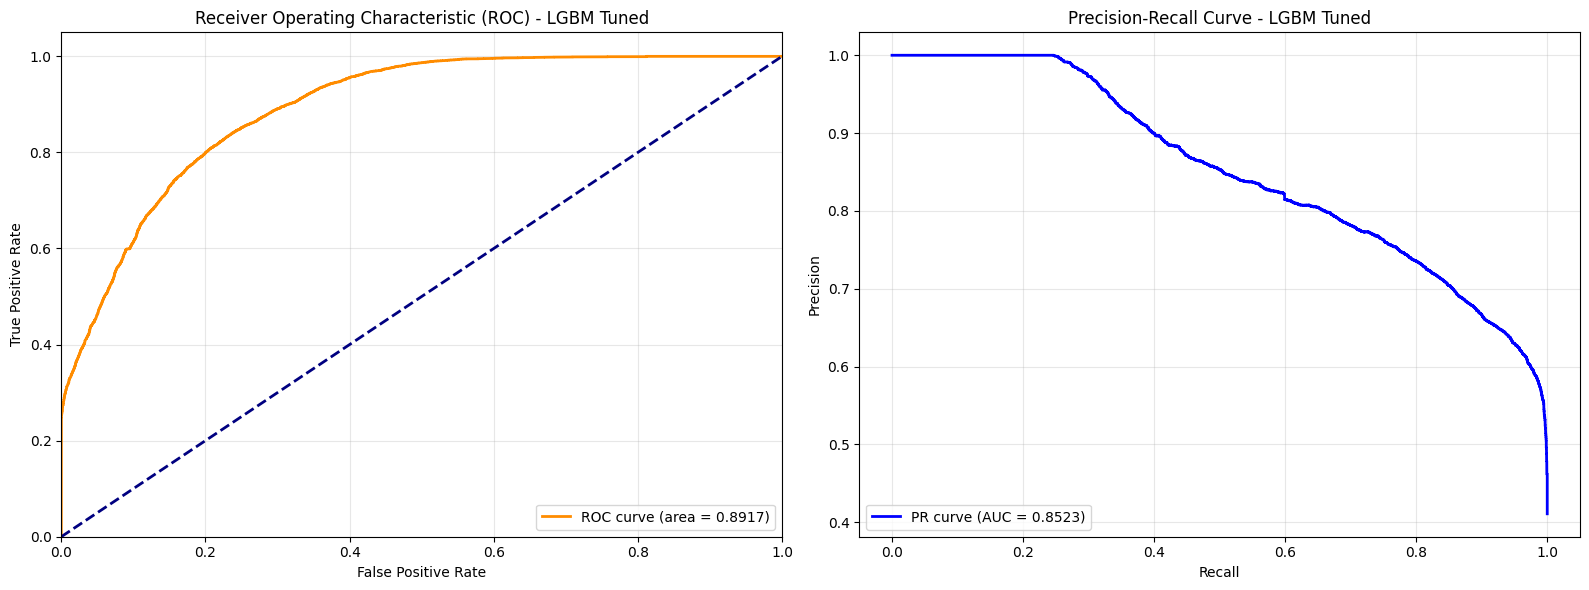

ROC-AUC Score: 0.8917
PR-AUC Score : 0.8523


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score


# Calculate ROC and AUC
fpr, tpr, _ = roc_curve(y_test, y_prob_tuned)
roc_auc_val = auc(fpr, tpr)

# Calculate Precision-Recall Curve and PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob_tuned)
pr_auc_val = average_precision_score(y_test, y_prob_tuned)

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(16, 6))


ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.4f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Receiver Operating Characteristic (ROC) - LGBM Tuned')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

ax[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc_val:.4f})')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve - LGBM Tuned')
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc_val:.4f}")
print(f"PR-AUC Score : {pr_auc_val:.4f}")

tuned LightGBM model demonstrated excellent performance with an ROC-AUC of 0.8917, indicating a strong ability to distinguish between cancelled and non cancelled bookings. Given the imbalanced nature of the dataset with the "cancelled" class representing the minority. The PR-AUC score of 0.8523 shows that the model effectively balances precision and recall, making it capable of detecting potential cancellations without generating an excessive number of false positive predictions.

## 2.2 Deep Learning Model

for the deep learning model we will use ANN and see if it's better than LGB Classifier

In [ ]:
# install the library for neural network
!pip install tensorflow

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import numpy as np

# Data scaling is very important for ANN so that features with large numbers do not dominate
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to float32 for TensorFlow
X_train_tf = X_train_scaled.astype('float32')
X_test_tf = X_test_scaled.astype('float32')
y_train_tf = y_train.values.astype('float32')
y_test_tf = y_test.values.astype('float32')

# Calculate Class Weights dynamically
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights))
print(f"Applied Class Weights: {class_weights}")

n_features = X_train_tf.shape[1]

# Build the model using Keras Input layer
model = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Training the model with Early Stopping and Class Weights
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

print(f"training with {n_features} ")
model_history = model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_test_tf, y_test_tf),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Applied Class Weights: {0: np.float64(0.7900665642601127), 1: np.float64(1.3618711385701676)}
training with 27 
Epoch 1/100
1447/1447 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8176 - loss: 0.3817 - val_accuracy: 0.7700 - val_loss: 0.4483
Epoch 2/100
1447/1447 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8430 - loss: 0.3285 - val_accuracy: 0.7782 - val_loss: 0.4430
Epoch 3/100
1447/1447 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8499 - loss: 0.3175 - val_accuracy: 0.7794 - val_loss: 0.4600
Epoch 4/100
1447/1447 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8540 - loss: 0.3113 - val_accuracy: 0.7880 - val_loss: 0.4292
Epoch 5/100
1447/1447 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8569 - loss: 0.3054 - val_accuracy: 0.7865 - val_loss: 0.4356
Epoch 6/100
1447/1447 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8597 - loss: 0.3015 - val_accuracy: 0.7928 - val_loss: 0.4225
Epoch 7/100
1447/1447 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8593 - loss: 0.2984 - val_accurac

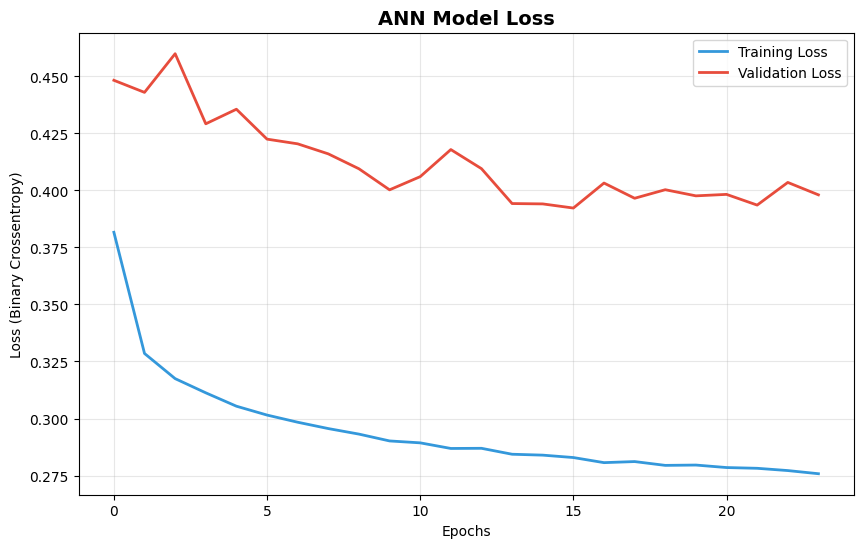

In [ ]:
# Visualize ANN Training & Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(model_history.history['loss'], label='Training Loss', color='#3498db', lw=2)
plt.plot(model_history.history['val_loss'], label='Validation Loss', color='#e74c3c', lw=2)

plt.title('ANN Model Loss', fontweight='bold', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The training loss curve consistently decreased from approximately 0.38 to 0.27, indicating that the model was increasingly effective at learning patterns in the training data. Meanwhile, the validation loss also decreased during the initial phase of training before stabilizing around 0.39, with only minor fluctuations.Overall, the model demonstrates good generalization capabilities regarding unseen data.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_prob_ann = model.predict(X_test_tf)


y_pred_ann = (y_prob_ann >= 0.5).astype(int)

#  Classification Report
print("=== CLASSIFICATION REPORT: ANN MODEL ===")
print(classification_report(y_test, y_pred_ann, digits=4))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

724/724 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
=== CLASSIFICATION REPORT: ANN MODEL ===
              precision    recall  f1-score   support

           0     0.8601    0.7852    0.8209     13635
           1     0.7262    0.8169    0.7689      9511

    accuracy                         0.7982     23146
   macro avg     0.7932    0.8011    0.7949     23146
weighted avg     0.8051    0.7982    0.7996     23146

Confusion Matrix:
[[10706  2929]
 [ 1741  7770]]


### Threshold Tuning

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

y_pred_ann_prob = model.predict(X_test_tf)
y_true_ann = y_test.values

thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores_ann = []

for t in thresholds:
    y_pred_t = (y_pred_ann_prob >= t).astype(int)
    f1_scores_ann.append(f1_score(y_true_ann, y_pred_t))


best_idx_ann = np.argmax(f1_scores_ann)
best_t_ann = thresholds[best_idx_ann]
best_f1_ann = f1_scores_ann[best_idx_ann]

print(f"TUNING THRESHOLD FOR ANN")
print(f"Optimal Threshold : {best_t_ann:.2f}")
print(f"Maximum F1-Score : {best_f1_ann:.4f}\n")


y_pred_ann_final = (y_pred_ann_prob >= best_t_ann).astype(int)

print(f"Classification Report for ANN (Threshold {best_t_ann:.2f}):")
print(classification_report(y_true_ann, y_pred_ann_final, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true_ann, y_pred_ann_final))

724/724 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
TUNING THRESHOLD FOR ANN
Optimal Threshold : 0.48
Maximum F1-Score : 0.7720

Classification Report for ANN (Threshold 0.48):
              precision    recall  f1-score   support

           0     0.8718    0.7676    0.8164     13635
           1     0.7156    0.8382    0.7720      9511

    accuracy                         0.7966     23146
   macro avg     0.7937    0.8029    0.7942     23146
weighted avg     0.8076    0.7966    0.7982     23146


Confusion Matrix:
[[10466  3169]
 [ 1539  7972]]


## 2.3 Model Comparison: LightGBM vs. ANN

| Metric (Class 1) | LightGBM (Tuned) | ANN (Tuned) |
| :--- | :---: | :---: |
| **Optimal Threshold** | 0.38 | 0.46 |
| **Precision** | 0.7079 | 0.7106 |
| **Recall** | 0.8458 | 0.8515 |
| **F1-Score** | 0.7707 | 0.7747 |
| **Accuracy** | 0.7932 | 0.7965 |
| **ROC-AUC** | 0.8917 | - |


Overall, the **ANN** model yields slightly superior results in terms of F1-Score (0.7747) and Recall (0.8515) compared to LightGBM. This indicates that the ANN is slightly more effective at capturing actual cancellations, which is crucial for hotel management in mitigating the risk of lost revenue.

## 2.4 Feature Importance

For the model interpretation stage utilizing Feature Importance and SHAP, LightGBM was selected because it is a tree-based model that provides built-in Feature Importance values ​​and is supported by SHAP, enabling interpretations that are more accurate, consistent, and explainable down to the level of each feature's contribution to the prediction.

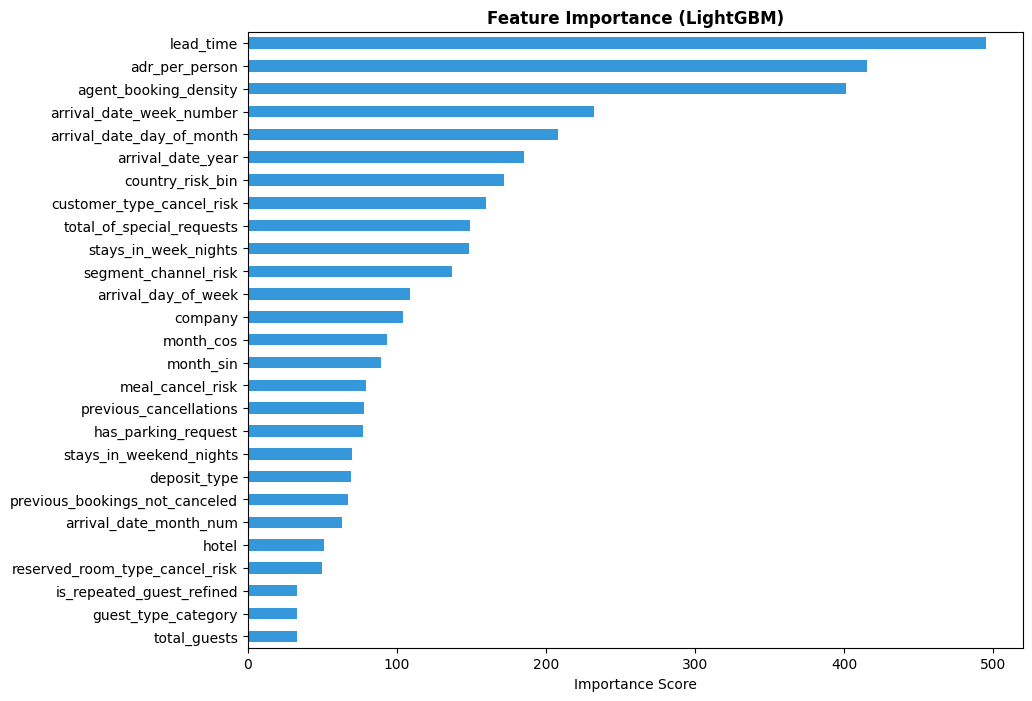

In [ ]:
best_model = lgb_tuned_model

feat_importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
feat_importances = feat_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_importances.plot(kind='barh', color='#3498db')
plt.title("Feature Importance (LightGBM)", fontweight='bold')
plt.xlabel("Importance Score")
plt.show()


- Lead time is the most influential feature in predicting booking cancellations, followed by ADR per person and agent booking density.
- Factors related to arrival time (week, day, and year) also make significant contributions, indicating the presence of temporal patterns in cancellations.
- features such as total_guests, guest_type_category, and is_repeated_guest_refined have a relatively minor influence on the model's predictions.

# COST SENSITIVE EVALUATION & PRESCRIPTIVE ANALYTICS

Feature Importance merely indicates the extent of a feature's contribution to the model but does not explain whether its influence increases or decreases of cancellation. To understand the direction and magnitude of each feature's impact on predictions, the analysis will proceed using SHAP (SHapley Additive exPlanations).

We will use the following mathematical formula to calculate the total cost of model errors: $$\text{Total Cost} = (FN \times C_{FN}) + (FP \times C_{FP})$$

- $C_{FN}$ = Cost of a suddenly vacant room due to a False Negative ($100).
- $C_{FP}$ = Cost of compensation/discount for overbooking due to a False Positive ($20).

## 3.1 Cost Matrix

In [ ]:
# from best threshold lgb tuned model
tn = 10316
fp = 3319
fn = 1467
tp = 8044

# Conversion rate (assuming 1 Euro = 1.08 Dollar)
EUR_TO_USD = 1.14

# Cost associated with False Negatives (taken from the mean of adr in euros)
C_FN = 100

# This compensation cost is much cheaper than leaving the room empty.
# It is estimated at around 20% of the room rate = €20.
C_FP = 20 # Cost associated with False Positives

# cost loss  with machine learning
cost_ml = (fn * C_FN) + (fp * C_FP)

# cost loss without Machine Learning
total_actual_canceled = fn + tp
cost_no_ml = total_actual_canceled * C_FN

savings_euro = cost_no_ml - cost_ml
savings_pct = (savings_euro / cost_no_ml) * 100

print("=========================================================")
print(" FINANCIAL COST SIMULATION (COST MATRIX) ")
print("=========================================================")
print(f"Total Test Data Samples : {tn + fp + fn + tp:,} reservation")
print(f"Losses WITHOUT Machine Learning : €{cost_no_ml:,.2f} (${cost_no_ml * EUR_TO_USD:,.2f})")
print(f"Loss WITH LightGBM Model : €{cost_ml:,.2f} (${cost_ml * EUR_TO_USD:,.2f})")
print("--------------------------------------------------------------")
print(f"MONEY SAVED : €{savings_euro:,.2f} (${savings_euro * EUR_TO_USD:,.2f})")
print(f"LOSS SUPPRESSION EFFICIENCY : {savings_pct:.2f}%")
print("=========================================================")

 FINANCIAL COST SIMULATION (COST MATRIX) 
Total Test Data Samples : 23,146 reservation
Losses WITHOUT Machine Learning : €951,100.00 ($1,084,254.00)
Loss WITH LightGBM Model : €213,080.00 ($242,911.20)
--------------------------------------------------------------
MONEY SAVED : €738,020.00 ($841,342.80)
LOSS SUPPRESSION EFFICIENCY : 77.60%


By implementing the LightGBM model (with a tuned threshold of 0.38), the hotel successfully reduced potential financial losses from cancellations by 77.60%—equivalent to securing €738,020 in potential revenue based on the test data. This demonstrates that lowering the probability threshold is effective in significantly minimizing False Negative costs

## 3.2 Dynamic Overbooking & Risk-Based Segmentation

We group guests based on model output probabilities for actionable operational steps.

In [ ]:
# Use probabilities from the tuned LightGBM model
y_prob_final = lgb_tuned_model.predict_proba(X_test)[:, 1]

# Segment probabilities into business risk zones
conditions = [
    (y_prob < 0.30),
    (y_prob >= 0.30) & (y_prob <= 0.38),
    (y_prob > 0.38)
]
choices = ['Low Risk', 'Medium Risk', 'High Risk']

test_df_business = test_df.copy()
test_df_business['Risk_Level'] = np.select(conditions, choices, default='Unknown')
test_df_business['Predicted_Prob'] = y_prob_final

print("=== GUEST RISK DISTRIBUTION FOR BUSINESS ACTIONS ===")
risk_summary = test_df_business['Risk_Level'].value_counts()
print(f"🟢 Low Risk (< 0.3)     : {risk_summary.get('Low Risk', 0):,}")
print(f"🟡 Medium Risk (0.3-0.7): {risk_summary.get('Medium Risk', 0):,}")
print(f"🔴 High Risk (> 0.7)    : {risk_summary.get('High Risk', 0):,}")

=== GUEST RISK DISTRIBUTION FOR BUSINESS ACTIONS ===
🟢 Low Risk (< 0.3)     : 9,503
🟡 Medium Risk (0.3-0.7): 1,293
🔴 High Risk (> 0.7)    : 12,350


For low-risk guests, no special measures are taken. For medium-risk guests, we can send reminder emails or breakfast promotion offers. For high-risk guests, the hotel can open up overbooking slots and require a non-refundable deposit to mitigate the risk of cancellation.

## 3.3 Prescriptive Analytics

In [ ]:
# PRESCRIPTIVE COUNTERFACTUAL SCENARIO

# Select 1 guest sample from the Medium/High Risk group
sample_idx = test_df_business[test_df_business['Risk_Level'].isin(['Medium Risk', 'High Risk'])].index[0]
guest_original = X_test.loc[[sample_idx]].copy()

# Initial Probability
prob_awal = lgb_tuned_model.predict_proba(guest_original)[:, 1][0]

print(f"=== BUSINESS PRESCRIPTIVE ANALYSIS (CUSTOMER #{sample_idx}) ===")
print(f"Initial Risk Status          : {test_df_business.loc[sample_idx, 'Risk_Level']}")
print(f"Initial Cancellation Prob.   : {prob_awal:.1%}")
print("-" * 55)


# First intervention: offering a Free Parking Slot (has_parking_request = 1)

guest_sim_1 = guest_original.copy()
guest_sim_1['has_parking_request'] = 1
prob_sim_1 = lgb_tuned_model.predict_proba(guest_sim_1)[:, 1][0]
drop_1 = (prob_awal - prob_sim_1) * 100

print(f"[Scenario A] Providing/Confirming Free Parking Slot:")
print(f" New Probability          : {prob_sim_1:.1%}")
print(f" Risk Reduction           : {drop_1:.1f} percentage points")
print("-" * 55)


# Second intervention: Interactive engagement (Encouraging Guest to submit Special Requests)
guest_sim_2 = guest_original.copy()
guest_sim_2['total_of_special_requests'] = guest_sim_2['total_of_special_requests'] + 2
prob_sim_2 = lgb_tuned_model.predict_proba(guest_sim_2)[:, 1][0]
drop_2 = (prob_awal - prob_sim_2) * 100

print(f"[Scenario B] Asking the guest to fulfill 2 special requests:")
print(f" New Probability          : {prob_sim_2:.1%}")
print(f" Risk Reduction           : {drop_2:.1f} percentage points")
print("-" * 55)


# COMBINED INTERVENTION
guest_sim_combo = guest_original.copy()
guest_sim_combo['has_parking_request'] = 1
guest_sim_combo['total_of_special_requests'] = guest_sim_combo['total_of_special_requests'] + 1
prob_combo = lgb_tuned_model.predict_proba(guest_sim_combo)[:, 1][0]
drop_combo = (prob_awal - prob_combo) * 100

print(f"Parking Confirmation(1) + Add 1 Special Request:")
print(f" Final Probability        : {prob_combo:.1%}")
print(f" TOTAL RISK REDUCTION     : {drop_combo:.1f} percentage points")

=== BUSINESS PRESCRIPTIVE ANALYSIS (CUSTOMER #0) ===
Initial Risk Status          : High Risk
Initial Cancellation Prob.   : 36.6%
-------------------------------------------------------
[Scenario A] Providing/Confirming Free Parking Slot:
 New Probability          : 0.1%
 Risk Reduction           : 36.5 percentage points
-------------------------------------------------------
[Scenario B] Asking the guest to fulfill 2 special requests:
 New Probability          : 22.7%
 Risk Reduction           : 13.9 percentage points
-------------------------------------------------------
Parking Confirmation(1) + Add 1 Special Request:
 Final Probability        : 0.1%
 TOTAL RISK REDUCTION     : 36.5 percentage points


Based on counterfactual intervention analysis, the variables `has_parking_request` and `total_of_special_requests` have been empirically proven to be the most effective operational levers for reducing cancellation risk. The hotel operations team is advised to move beyond passive deposit collection and instead adopt proactive approaches—such as confirming free parking slot allocations or sending service preference surveys (regarding special requests) to guests classified as "High Risk."

## 3.4 Visualizing Model Interpretation with SHAP

SHAP (SHapley Additive exPlanations) is used to see how the LightGBM model makes decisions. We will examine both the global view (which features are most influential overall) and the local view (the specific reasons why a guest in a sample scenario is categorized as high-risk).

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



Global SHAP Summary Plot


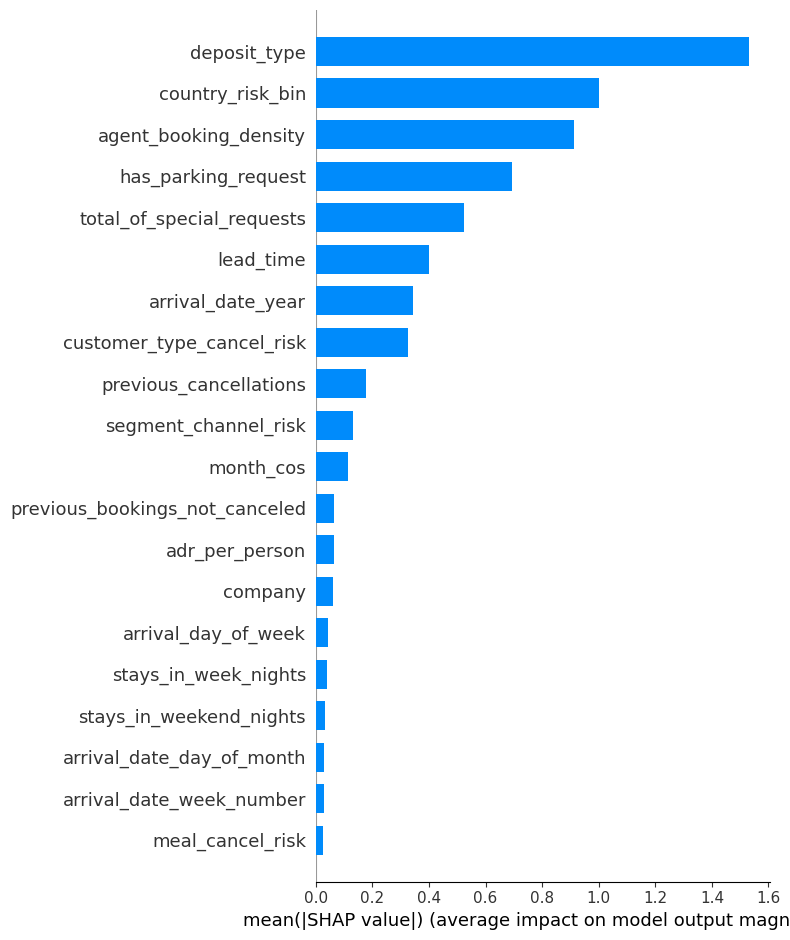


Force Plot for Guest #0


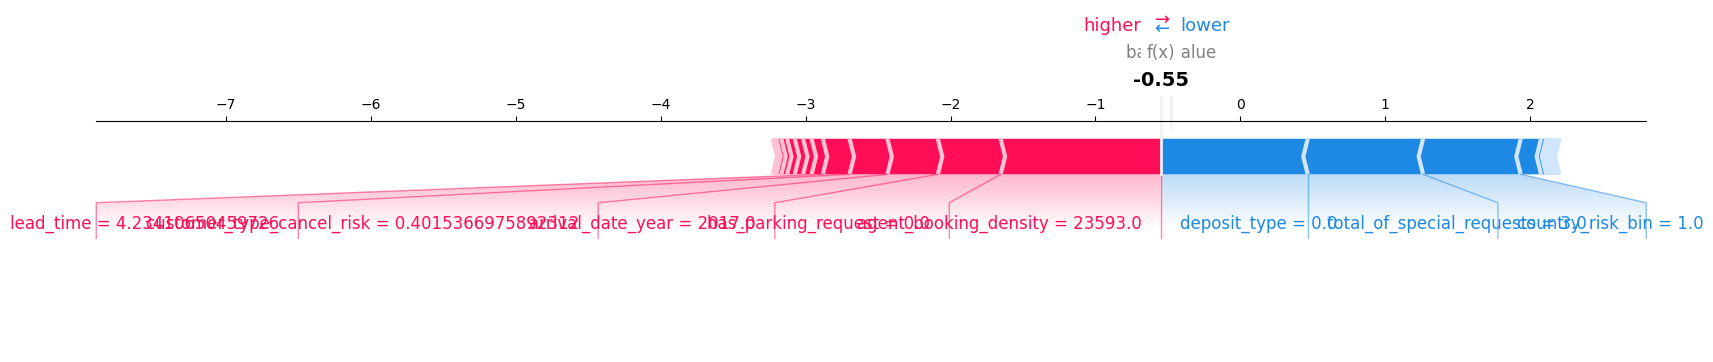

In [ ]:
import shap

# Initialize JS for SHAP visualization in the notebook
shap.initjs()
explainer = shap.TreeExplainer(lgb_tuned_model)
shap_vals = explainer.shap_values(X_test)

# Extract SHAP values ​​for the positive class
shap_values_class_1 = shap_vals
base_value = explainer.expected_value

# Global Interpretation
print("Global SHAP Summary Plot")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_class_1, X_test, plot_type="bar")
plt.show()

# Local Interpretation: Force Plot for the guest sample used in the simulation (sample_idx)
print(f"\nForce Plot for Guest #{sample_idx}")
shap.force_plot(
    base_value,
    shap_values_class_1[sample_idx, :],
    X_test.iloc[sample_idx, :],
    matplotlib=True
)
plt.show()

**SHAP Analysis**

The `deposit_type` is the most influential factor regarding cancellation predictions, followed by `country_risk_bin` and `agent_booking_density`. Meanwhile, features such as `meal_cancel_risk`, `arrival_date_week_number`, and `arrival_date_day_of_month` have a relatively minor impact.

**SHAP Force Plot for our Scenario Guests**

In this prediction example, the features `lead_time`, `customer_type_cancel_risk`, `arrival_date_year`, `has_parking_request`, and `agent_booking_density` push the prediction toward a cancellation (red). Conversely, `deposit_type`, `country_risk_bin`, and `total_of_special_requests` contribute to reducing the likelihood of cancellation (blue).

# EVALUATION

---

### 1. Conclusions & Key Insights

*   The optimized LightGBM model (using a decision threshold of 0.38) achieved an F1-Score of 0.7707 and a Recall of 84.58%, ensuring that the majority of potential cancellations are detected before they occur.
*   Cost Matrix simulations demonstrated a 77.60% reduction in potential losses due to vacant rooms (saving up to €738,020 in potential revenue based on test data), assuming costs of €100 for False Negatives and €20 for False Positives.
*   SHAP analysis confirmed that the availability of parking slots (`has_parking_request`) and a high number of special requests (`total_of_special_requests`) are the strongest indicators that a guest will actually arrive.
*   Long booking lead times, a history of prior cancellations, and associations with high-risk booking agents are primary drivers of increased cancellation probability.
*   The `deposit_type` variable (specifically "Non-Refundable") shows an inherent correlation with high cancellation rates, driven by the prevalence of bulk bookings from specific travel agencies.

---

### 2. Business Recommendations

*   **Automated Risk Segmentation System:**
    *   **Low Risk ($P < 0.30$):** No intervention required; proceed with standard reservation processes.
    *   **Medium Risk ($0.30 \le P \le 0.38$):** Send a friendly reminder email and confirm the arrival schedule 7 days prior to check-in.
    *   **High Risk ($P > 0.38$):** Trigger automated operational interventions and dynamic overbooking strategies.

*   **Proactive Customer Intervention:**
    *   Avoid rigid deposit collection policies. Instead, foster engagement by offering commitment-enhancing perks—such as **confirmed free parking** or **room preference fulfillment** (special requests). Counterfactual simulations demonstrate that parking-related interventions can reduce cancellation risk by up to **36.5 percentage points**.

* **Measured Dynamic Overbooking Strategy:**
  * Utilize predictions of "High Risk" class accumulation to set daily overbooking quotas specifically for standard room types; this ensures occupancy rates approach 100% while avoiding the risk of severe room shortages.

---

### 3. Further Development & Research

* Integrate advanced feature engineering based on external data—such as local weather indicators, flight trends, and the Portuguese national holiday calendar—to capture key variables beyond historical reservation data.
* Implement a Dynamic Cost Matrix that adjusts loss cost variables (False Negatives) based on actual daily room rates (transaction-specific ADR) rather than a constant average value (€100).
* Build an integrated MLOps pipeline using Docker and FastAPI, complete with Data Drift and Concept Drift monitoring systems, to ensure consistent model performance during deployment in a real-world hotel system.

**THANK YOUR FOR READING THIS NOTEBOOK**

**GitHub Repository**
Full project structure and notebooks:

Hotel Booking Cancellation Prediction(https://github.com/KentKan12/Hotel_Booking_Cancellation_Prediction)

In [ ]:
# for deployment purpose
import joblib


customer_type_map = train_df_raw.groupby('customer_type')['is_canceled'].mean().to_dict()
meal_map = train_df_raw.groupby('meal')['is_canceled'].mean().to_dict()
room_map = train_df_raw.groupby('reserved_room_type')['is_canceled'].mean().to_dict()
model_artifacts = {
    'model': lgb_tuned_model,
    'target_encoder': target_encoder,
    'best_threshold': best_t_lgbm, # Nilai 0.38
    'global_mean_train': global_mean_train,
    'country_risk_mapping': country_risk_mapping,
    'agent_frequency_map': agent_frequency_map,
    'customer_type_map': customer_type_map,
    'meal_map': meal_map,
    'room_map': room_map,
    'feature_names': list(X_train.columns)
}


joblib.dump(model_artifacts, 'hotel_cancellation_model.joblib')

DONE
